## Frame

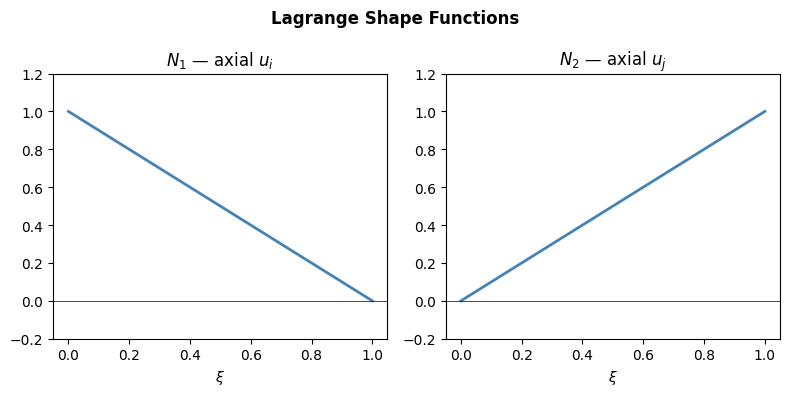

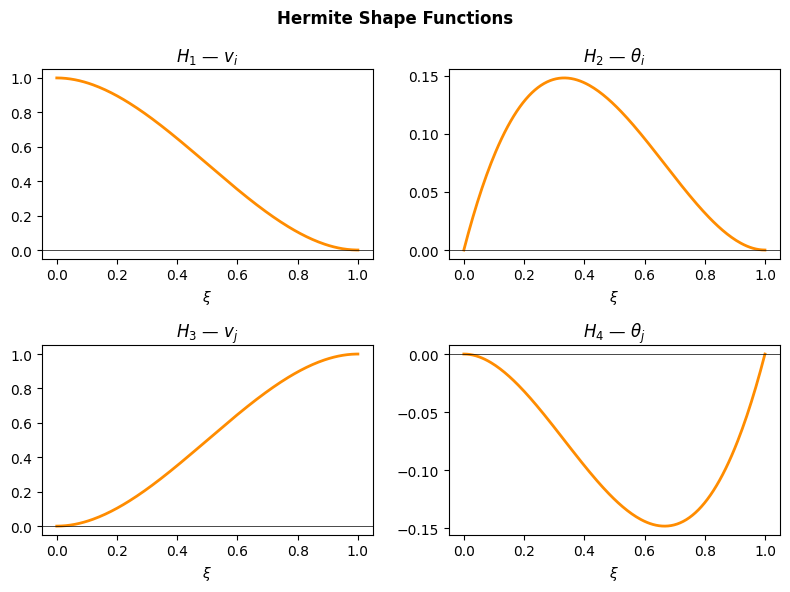

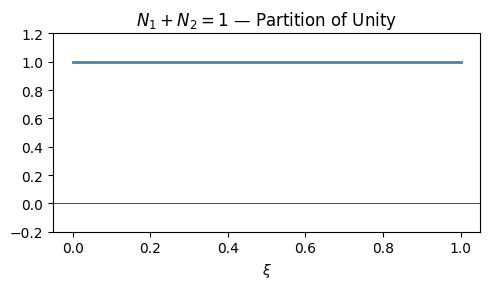

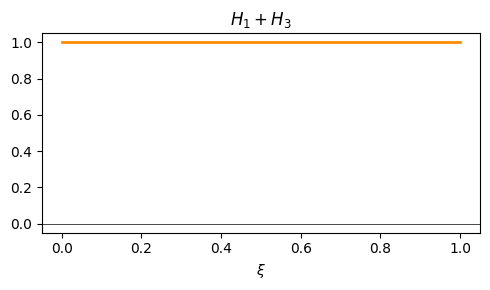

In [4]:
import numpy as np
import matplotlib.pyplot as plt

L  = 1.0
xi = np.linspace(0, 1, 200)

# Lagrange
N1 = 1 - xi
N2 = xi

# Hermite
H1 =  1 - 3*xi**2 + 2*xi**3
H2 =  L*(xi - 2*xi**2 + xi**3)
H3 =  3*xi**2 - 2*xi**3
H4 =  L*(-xi**2 + xi**3)

# --- Lagrange ---
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].plot(xi, N1, color='steelblue', lw=2)
axes[0].set_title('$N_1$ — axial $u_i$')
axes[0].set_xlabel('$\\xi$')
axes[1].plot(xi, N2, color='steelblue', lw=2)
axes[1].set_title('$N_2$ — axial $u_j$')
axes[1].set_xlabel('$\\xi$')
for ax in axes:
    ax.axhline(0, color='k', lw=0.5)
    ax.set_ylim(-0.2, 1.2)
fig.suptitle('Lagrange Shape Functions', fontweight='bold')
plt.tight_layout()
plt.show()

# --- Hermite ---
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
hermite = [H1, H2, H3, H4]
titles  = ['$H_1$ — $v_i$', '$H_2$ — $\\theta_i$',
           '$H_3$ — $v_j$', '$H_4$ — $\\theta_j$']
for i, ax in enumerate(axes.flat):
    ax.plot(xi, hermite[i], color='darkorange', lw=2)
    ax.axhline(0, color='k', lw=0.5)
    ax.set_title(titles[i])
    ax.set_xlabel('$\\xi$')
fig.suptitle('Hermite Shape Functions', fontweight='bold')
plt.tight_layout()
plt.show()


# --- Sum of Lagrange ---
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(xi, N1 + N2, color='steelblue', lw=2)
ax.axhline(0, color='k', lw=0.5)
ax.set_ylim(-0.2, 1.2)
ax.set_title('$N_1 + N_2 = 1$ — Partition of Unity')
ax.set_xlabel('$\\xi$')
plt.tight_layout()
plt.show()

# --- Sum of Hermite ---
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(xi, H1 + H3, color='darkorange', lw=2)
ax.axhline(0, color='k', lw=0.5)
ax.set_title('$H_1 + H_3$')
ax.set_xlabel('$\\xi$')
plt.tight_layout()
plt.show()

# # --- Sum of Hermite ---
# fig, ax = plt.subplots(figsize=(5, 3))
# ax.plot(xi, H2 + H4, color='darkorange', lw=2)
# ax.axhline(0, color='k', lw=0.5)
# ax.set_title('$H_1 + H_2 + H_3 + H_4$')
# ax.set_xlabel('$\\xi$')
# plt.tight_layout()
# plt.show()

## CST

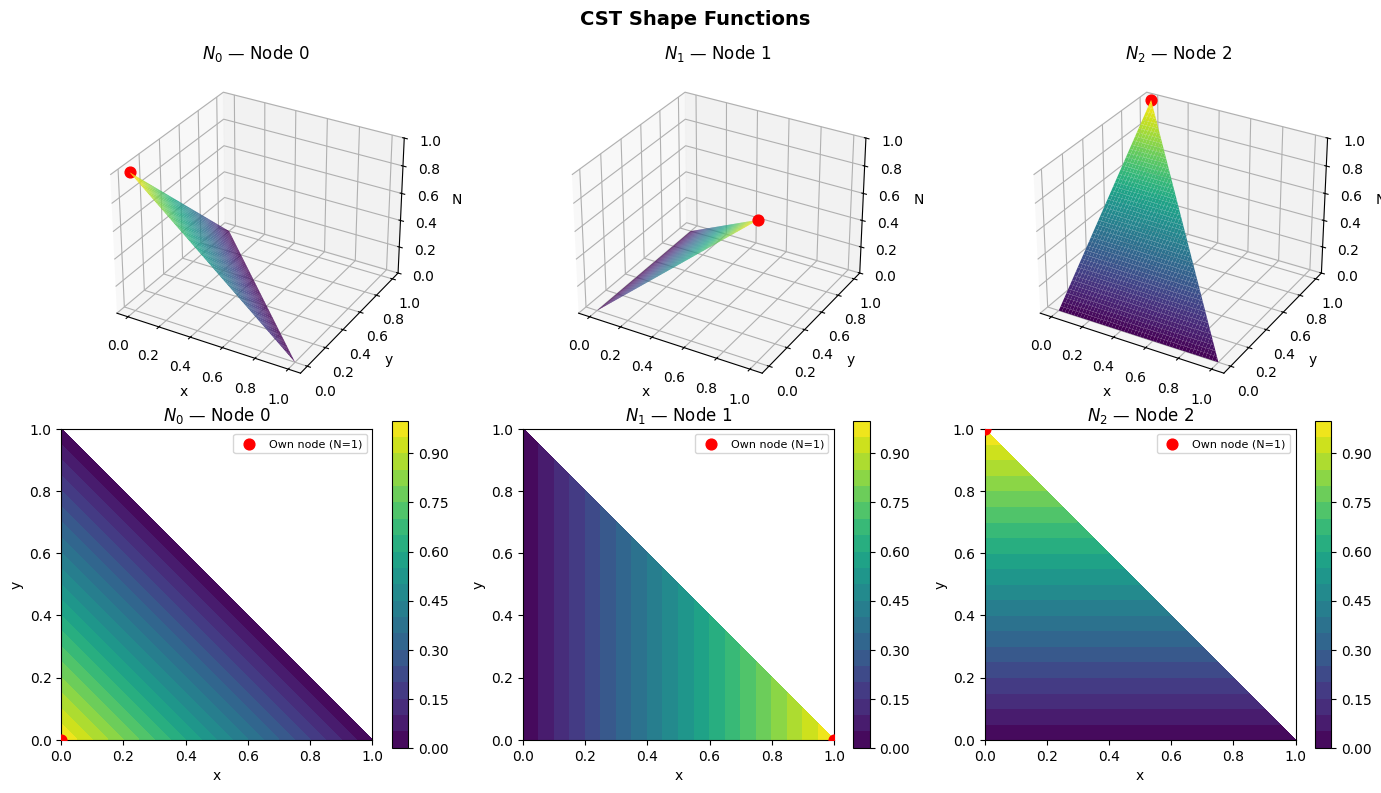

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Node coordinates (counter-clockwise)
x0, y0 = 0.0, 0.0
x1, y1 = 1.0, 0.0
x2, y2 = 0.0, 1.0

# Grid in natural coordinates
n = 500
xi  = np.linspace(0, 1, n)
eta = np.linspace(0, 1, n)
XI, ETA = np.meshgrid(xi, eta)

# Mask: only points inside the triangle
mask = (XI + ETA <= 1)

# Cartesian coordinates of the grid
X = x0 + (x1-x0)*XI + (x2-x0)*ETA
Y = y0 + (y1-y0)*XI + (y2-y0)*ETA

# CST shape functions: N_i = xi_i
N0 = np.where(mask, 1 - XI - ETA, np.nan)  # node 0
N1 = np.where(mask, XI,            np.nan)  # node 1
N2 = np.where(mask, ETA,           np.nan)  # node 2

shapes = [N0, N1, N2]
labels = ['$N_0$ — Node 0', '$N_1$ — Node 1', '$N_2$ — Node 2']
nodes  = [(x0, y0), (x1, y1), (x2, y2)]

fig = plt.figure(figsize=(14, 8))

for i in range(3):
    # 3D view
    ax3d = fig.add_subplot(2, 3, i+1, projection='3d')
    ax3d.plot_surface(X, Y, shapes[i], cmap='viridis')
    ax3d.scatter(*nodes[i], 1.0, color='red', s=60, zorder=5)
    ax3d.set_title(labels[i])
    ax3d.set_xlabel('x')
    ax3d.set_ylabel('y')
    ax3d.set_zlabel('N')
    ax3d.set_zlim(0, 1)

    # Plan view
    ax2d = fig.add_subplot(2, 3, i+4)
    cp = ax2d.contourf(X, Y, shapes[i], levels=20, cmap='viridis', vmin=0, vmax=1)
    plt.colorbar(cp, ax=ax2d)
    ax2d.scatter(*nodes[i], color='red', s=60, zorder=5, label='Own node (N=1)')
    ax2d.set_title(labels[i])
    ax2d.set_xlabel('x')
    ax2d.set_ylabel('y')
    ax2d.set_aspect('equal')
    ax2d.legend(fontsize=8)

fig.suptitle('CST Shape Functions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()